<a href="https://colab.research.google.com/github/Cristiand056/practicas_IA/blob/main/Breats_cancer_with_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("obulisainaren/multi-cancer")

print("Path to dataset files:", path)

100%|██████████| 8.62G/8.62G [01:56<00:00, 79.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3


In [53]:
import os
import numpy as np

In [3]:
path_breats_cancer = "/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/Breast Cancer"

In [4]:
total_images = 0
subclasses = [d for d in os.listdir(path_breats_cancer) if os.path.isdir(os.path.join(path_breats_cancer, d))]
print("Subclases (si hay):", subclasses)

Subclases (si hay): ['breast_benign', 'breast_malignant']


In [5]:
if subclasses:
    for sub in subclasses:
        sub_path = os.path.join(path_breats_cancer, sub)
        num_imgs = len([f for f in os.listdir(sub_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        print(f"{sub}: {num_imgs} imágenes")
        total_images += num_imgs
else:
    num_imgs = len([f for f in os.listdir(path_breats_cancer) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    print(f"Imágenes directas: {num_imgs}")
    total_images = num_imgs

print(f"Total de imágenes de cáncer de seno: {total_images}")

breast_benign: 5000 imágenes
breast_malignant: 5000 imágenes
Total de imágenes de cáncer de seno: 10000


In [6]:
from PIL import Image
import matplotlib.pyplot as plt

def show_samples(path, num_samples=5):
    image_files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:num_samples]
    if not image_files:
        print("No hay imágenes en esta carpeta.")
        return

    fig, axes = plt.subplots(1, len(image_files), figsize=(15, 3))
    axes = axes if len(image_files) > 1 else [axes]
    for i, ax in enumerate(axes):
        img_path = os.path.join(path, image_files[i])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(image_files[i][:15])  # Título corto
    plt.show()


Mostrando muestras de: breast_benign


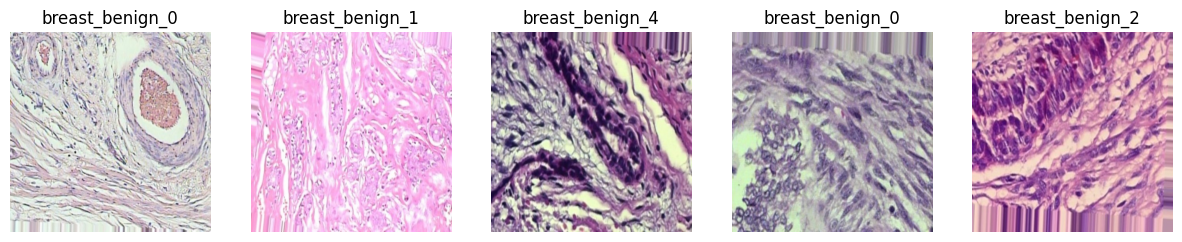

In [7]:
if subclasses:
    sample_sub_path = os.path.join(path_breats_cancer, subclasses[0])
    print(f"Mostrando muestras de: {subclasses[0]}")
    show_samples(sample_sub_path)
else:
    print("Mostrando muestras directas:")
    show_samples(path_breats_cancer)

Mostrando muestras de: breast_malignant


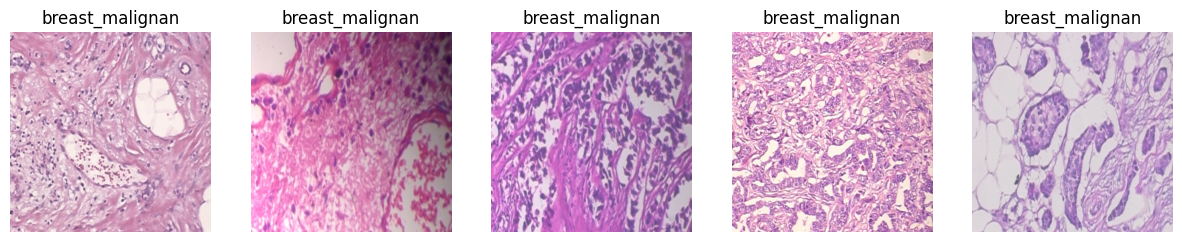

In [8]:
if subclasses:
    sample_sub_path = os.path.join(path_breats_cancer, subclasses[1])
    print(f"Mostrando muestras de: {subclasses[1]}")
    show_samples(sample_sub_path)
else:
    print("Mostrando muestras directas:")
    show_samples(path_breats_cancer)

In [12]:
sample_dir = os.path.join(path_breats_cancer, subclasses[0])

sample_img_file = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][0]

sample_img_path = os.path.join(sample_dir, sample_img_file)

sample_img = Image.open(sample_img_path)

print("Tamaño de la imagen:", sample_img.size)
print("Modo de la imagen:", sample_img.mode)
print("Formato de la imagen:", sample_img.format)

Tamaño de la imagen: (512, 512)
Modo de la imagen: RGB
Formato de la imagen: JPEG


In [36]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_input if len(subclasses) > 1 else None,
    #color_mode='grayscale'
)

train_gen = train_datagen.flow_from_directory(
    path_breats_cancer,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' if len(subclasses) > 1 else 'binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=preprocess_input
    #color_mode='grayscale'
)

val_gen = val_datagen.flow_from_directory(
    path_breats_cancer,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' if len(subclasses) > 1 else 'binary',
    subset='validation',
    shuffle=False,
    seed=42
)

# Prints para depurar
print("Clases detectadas:", train_gen.class_indices)
print("Número de clases:", len(subclasses))
print("Muestras de entrenamiento:", train_gen.samples)
print("Muestras de validación:", val_gen.samples)
print("Batch size:", train_gen.batch_size)

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Clases detectadas: {'breast_benign': 0, 'breast_malignant': 1}
Número de clases: 2
Muestras de entrenamiento: 8000
Muestras de validación: 2000
Batch size: 32


In [33]:
batch_images, _ = next(train_gen)
print("Forma del batch (batch_size, alto, ancho, canales):", batch_images.shape)
print("Número de canales:", batch_images.shape[-1])

Forma del batch (batch_size, alto, ancho, canales): (32, 224, 224, 3)
Número de canales: 3


In [34]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Input(shape=(224, 224, 3)))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(subclasses), activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,650 (91.20 MB)

 Trainable params: 23,907,650 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'recall'])
model.fit(train_gen, epochs=10, batch_size=32, validation_data=val_gen, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 948s 4s/step - accuracy: 0.8293 - loss: 1.0272 - recall: 0.8293 - val_accuracy: 0.8340 - val_loss: 0.4230 - val_recall: 0.8340
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 953s 4s/step - accuracy: 0.8901 - loss: 0.2932 - recall: 0.8901 - val_accuracy: 0.8215 - val_loss: 0.5715 - val_recall: 0.8215
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 932s 4s/step - accuracy: 0.9060 - loss: 0.2497 - recall: 0.9060 - val_accuracy: 0.8575 - val_loss: 0.4223 - val_recall: 0.8575
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 929s 4s/step - accuracy: 0.9107 - loss: 0.2288 - recall: 0.9107 - val_accuracy: 0.8720 - val_loss: 0.4811 - val_recall: 0.8720
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 930s 4s/step - accuracy: 0.9227 - loss: 0.2141 - recall: 0.9227 - val_accuracy: 0.9030 - val_loss: 0.3181 - val_recall: 0.9030
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 919s 4s/step - accuracy: 0.9262 - loss: 0.1854 - recall: 0.9262 - val_accuracy: 0.8470 - val_loss: 0.6773 - val_recall: 0.847

In [38]:
model.evaluate(val_gen)

63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9533 - loss: 0.1733 - recall: 0.9533


[0.38424503803253174, 0.9085000157356262, 0.9085000157356262]

In [40]:
model.save("modelo_cancer_senos.keras")

In [57]:
def show_images_to_compare(real_images, predicted_images, true_labels, pred_labels, num_samples=7, image_files=None):
    num_samples = min(num_samples, len(real_images), len(predicted_images), len(true_labels), len(pred_labels))

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))


    if num_samples == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    aleatori_list = [np.random.randint(0, len(real_images)) for i in range(num_samples)]

    for i in range(num_samples):

        img_real = Image.open(real_images[aleatori_list[i]])
        axes[0, i].imshow(img_real)
        axes[0, i].axis('off')
        real_title = f"Real: {true_labels[aleatori_list[i]]}"
        if image_files:
            real_title += f"\n{image_files[aleatori_list[i]][:15]}"
        axes[0, i].set_title(real_title, fontsize=10)

        img_pred = Image.open(predicted_images[aleatori_list[i]])
        axes[1, i].imshow(img_pred)
        axes[1, i].axis('off')
        pred_title = f"Pred: {pred_labels[aleatori_list[i]]}"
        if image_files:
            pred_title += f"\n{image_files[aleatori_list[i]][:15]}"
        axes[1, i].set_title(pred_title, fontsize=10)

    plt.tight_layout()
    plt.show()

In [59]:

# Reinicia val_gen y obtén predicciones (como en matriz de confusión)
val_gen.reset()
y_predict = model.predict(val_gen)
y_pred_classes = np.argmax(y_predict, axis=1)  # Para categorical; ajusta si binary

# Extrae y_true (labels verdaderos)
y_true_classes = val_gen.classes  # Directo de generador (integer labels)

# Extrae paths de imágenes (itera sobre val_gen.filenames)
image_paths = [os.path.join(path_breats_cancer, f) for f in val_gen.filenames]  # Ajusta breast_path
image_files = val_gen.filenames  # Nombres para títulos

# Convierte integers a strings de clases (usa class_indices)
class_names = list(val_gen.class_indices.keys())  # e.g., ['benign', 'malignant']
true_labels_str = [class_names[label] for label in y_true_classes]
pred_labels_str = [class_names[label] for label in y_pred_classes]

63/63 ━━━━━━━━━━━━━━━━━━━━ 63s 983ms/step


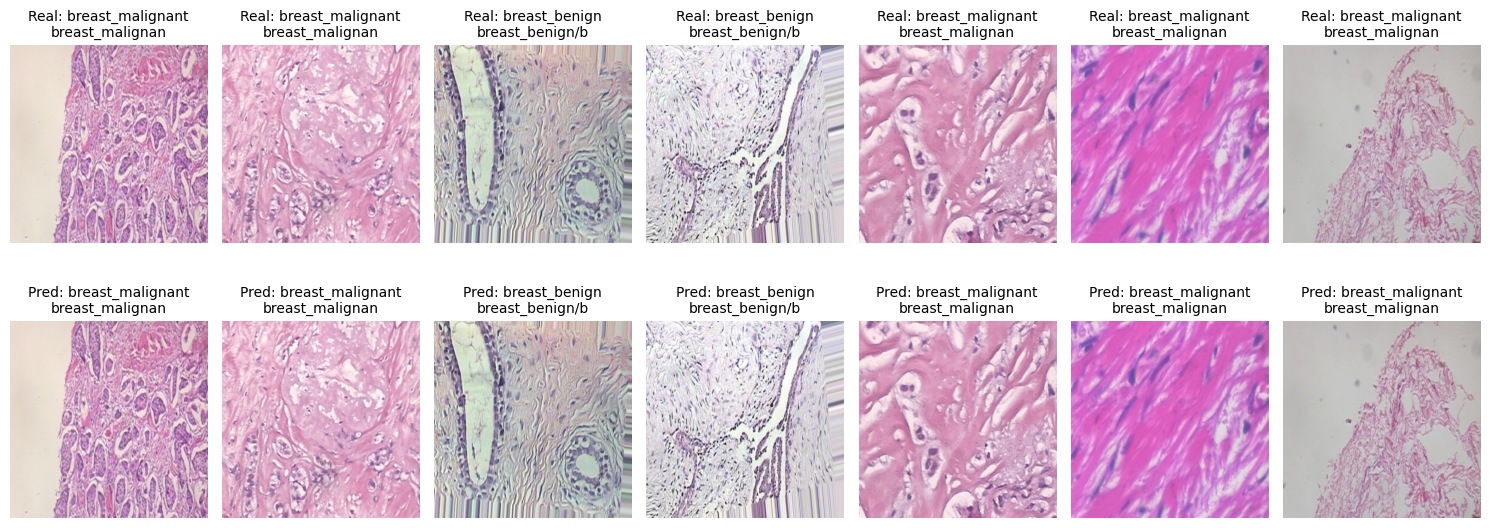

In [58]:
show_images_to_compare(image_paths, image_paths, true_labels_str, pred_labels_str, num_samples=7, image_files=image_files)